## **1. Importação das bibliotecas**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

## **2. Carregamento do Dataset**

In [ ]:
sheet_id = "1OmnQ7Yut5YDj-7n4LpLtceW8NGWWp3UW"
gid = "1420226095"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

df = pd.read_csv(url)


# **3. Visão Geral do Dataset**

In [ ]:
#dimensões
df.shape

(113634, 13)

In [ ]:
#tipo das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113634 entries, 0 to 113633
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Iso3_code            113634 non-null  object
 1   Country              113634 non-null  object
 2   Region               113634 non-null  object
 3   Subregion            113634 non-null  object
 4   Indicator            113634 non-null  object
 5   Dimension            113634 non-null  object
 6   Category             113634 non-null  object
 7   Sex                  113634 non-null  object
 8   Age                  113634 non-null  object
 9   Year                 113634 non-null  int64 
 10  Unit of measurement  113634 non-null  object
 11  VALUE                113634 non-null  object
 12  Source               113634 non-null  object
dtypes: int64(1), object(12)
memory usage: 11.3+ MB


In [ ]:
#primeiras linhas
df.head()

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,ARM,Armenia,Asia,Western Asia,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,35,CTS
1,CHE,Switzerland,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,28,CTS
2,COL,Colombia,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,15053,CTS
3,CZE,Czechia,Europe,Eastern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,69,CTS
4,DEU,Germany,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,455,CTS


In [ ]:
#estatisticas descritivas
df.describe()

,Year
count,113634.000000
mean,2014.684487
std,6.144394
min,1990.000000
25%,2012.000000
50%,2016.000000
75%,2019.000000
max,2022.000000


# **2. Limpeza e Tratamento**

In [ ]:
#valores nulos
df.isnull().sum()

,0
Iso3_code,0
Country,0
Region,0
Subregion,0
Indicator,0
Dimension,0
Category,0
Sex,0
Age,0
Year,0


In [ ]:
#remover duplicados
df = df.drop_duplicates()

In [ ]:
#verificar colunas categóricas
df.select_dtypes(include="object").nunique()

,0
Iso3_code,231
Country,231
Region,23
Subregion,23
Indicator,6
Dimension,6
Category,24
Sex,3
Age,11
Unit of measurement,2


Tratando a coluna de value (estava como tipo object, por convenção as estatiticas descritivas foi alterado para o tipo float64)

In [ ]:
df["VALUE"].head(20)


,VALUE
0,35
1,28
2,15053
3,69
4,455
5,70
6,2764
7,905
8,229
9,1


In [ ]:
df["VALUE"].dtype


dtype('O')

In [ ]:
df["VALUE"].sample(20)

,VALUE
47956,0
70047,"3,221753278"
102151,"0,6520995531"
44123,14
45227,5
64360,"1,23751914"
35292,9
78837,0
84843,"1,558078796"
23991,287


In [ ]:
df["VALUE"] = (
    df["VALUE"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

In [ ]:
df["VALUE"] = pd.to_numeric(
    df["VALUE"],
    errors="coerce"
)

In [ ]:
df["VALUE"].dtype

dtype('float64')

In [ ]:
df["VALUE"].isnull().sum()


np.int64(0)

# **3. Entendendo os Dados**

In [ ]:
#indicadores existentes
df["Indicator"].unique()

array(['Persons arrested/suspected for intentional homicide',
       'Victims of intentional homicide',
       'Victims of intentional homicide – City-level data',
       'Persons convicted for intentional homicide',
       'Death due to intentional homicide in prison',
       'Victims of Intentional Homicide - Regional Estimate'],
      dtype=object)

In [ ]:
#quantidade por indicador
df["Indicator"].value_counts()

,count
Indicator,
Victims of intentional homicide,85523
Persons arrested/suspected for intentional homicide,17817
Victims of intentional homicide – City-level data,4030
Victims of Intentional Homicide - Regional Estimate,2772
Persons convicted for intentional homicide,2472
Death due to intentional homicide in prison,1020


In [ ]:
#sexos disponiveis
df["Sex"].unique()

array(['Male', 'Female', 'Total'], dtype=object)

In [ ]:
#regiões disponiveis
df["Region"].unique()

array(['Asia', 'Europe', 'Americas', 'Africa', 'Oceania', 'World',
       'Australia and New Zealand', 'Central Asia', 'Eastern Asia',
       'Eastern Europe', 'Latin America and the Caribbean', 'Melanesia',
       'Micronesia', 'Northern Africa', 'Northern America',
       'Northern Europe', 'Polynesia', 'South-eastern Asia',
       'Southern Asia', 'Southern Europe', 'Sub-Saharan Africa',
       'Western Asia', 'Western Europe'], dtype=object)

# **4. Filtrando Apenas Homicídios**

In [ ]:
homicidios = df[
    (df["Indicator"] == "Victims of intentional homicide") &
    (df["Sex"] == "Total") &
    (df["Unit of measurement"] == "Rate per 100,000 population") &
    (df["Year"] >= 2013) &
    (df["Year"] <= 2022)
].copy()

In [ ]:
homicidios.head()

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
63796,ABW,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",5.832037,MD
63797,AIA,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",7.299270,WHO/NSO/SDG/PAHO
63798,ALB,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",4.295095,MD/CTS/GSH 2023 Revision/NSO
63799,AND,Andorra,Europe,Southern Europe,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",0.000000,Interpol/CTS
63800,ARE,United Arab Emirates,Asia,Western Asia,Victims of intentional homicide,Total,Total,Total,Total,2013,"Rate per 100,000 population",0.651291,CTS


In [ ]:
homicidios.shape

(9488, 13)

In [ ]:
#estatisticas dos homicicios
homicidios["VALUE"].describe()

,VALUE
count,9488.000000
mean,2.823336
std,7.178446
min,0.000000
25%,0.116347
50%,0.437131
75%,1.855709
max,106.819604


# **Distribuição dos Homicidios**

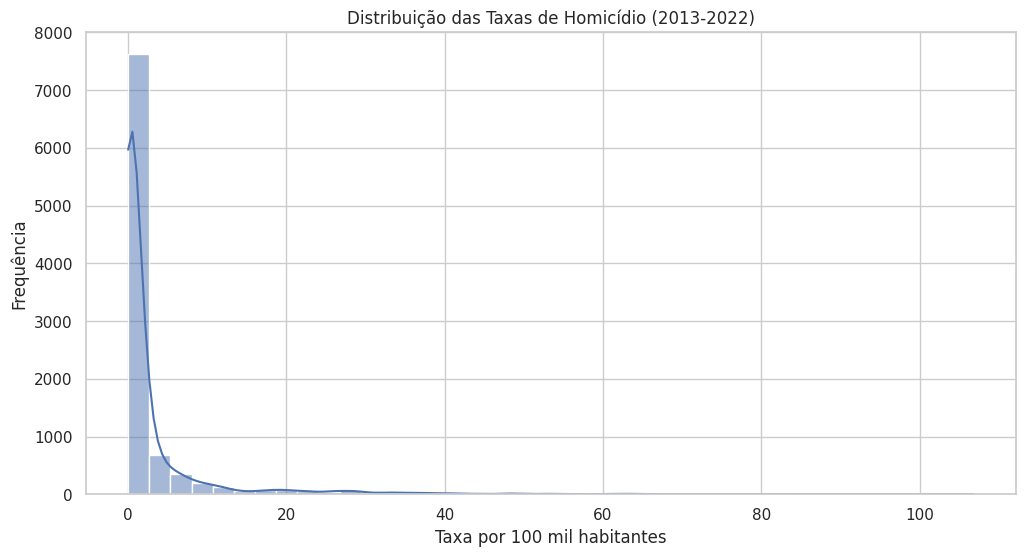

In [ ]:
sns.histplot(
    homicidios["VALUE"],
    bins=40,
    kde=True
)

plt.title("Distribuição das Taxas de Homicídio (2013-2022)")
plt.xlabel("Taxa por 100 mil habitantes")
plt.ylabel("Frequência")

plt.show()

In [ ]:
regioes = (
    homicidios
    .groupby("Region")["VALUE"]
    .mean()
    .sort_values(ascending=False)
)

regioes

,VALUE
Region,
Americas,5.595460
Africa,2.352568
Oceania,1.134564
Asia,1.035240
Europe,0.475159


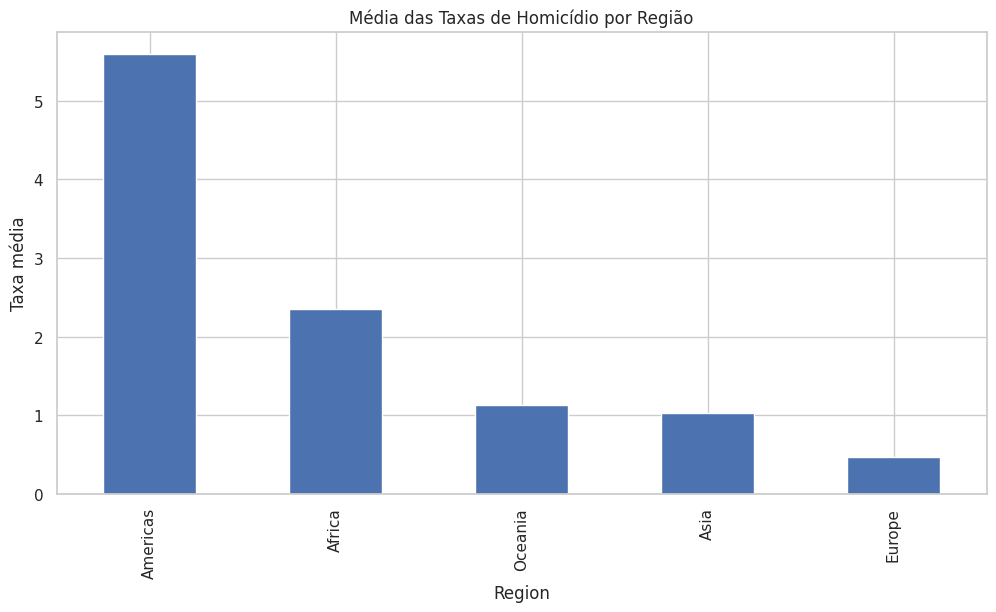

In [ ]:
regioes.plot(kind="bar")

plt.title("Média das Taxas de Homicídio por Região")
plt.ylabel("Taxa média")

plt.show()

In [ ]:
anos = (
    homicidios
    .groupby("Year")["VALUE"]
    .mean()
)

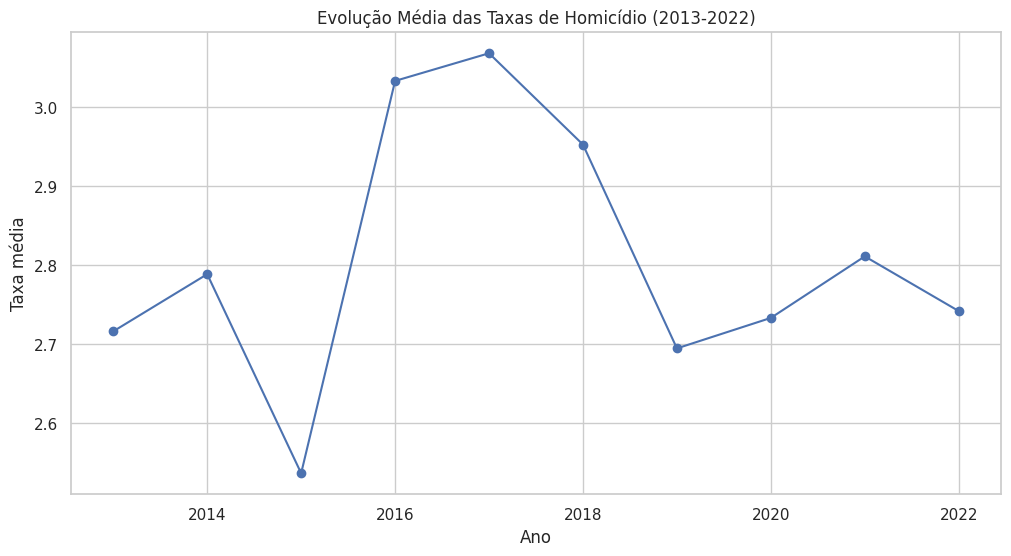

In [ ]:
anos.plot(marker="o")

plt.title("Evolução Média das Taxas de Homicídio (2013-2022)")
plt.xlabel("Ano")
plt.ylabel("Taxa média")

plt.show()

In [ ]:
top_paises = (
    homicidios
    .groupby("Country")["VALUE"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_paises

,VALUE
Country,
South Africa,34.311815
Venezuela (Bolivarian Republic of),34.309933
Iraq (Central Iraq),33.943127
Nigeria,27.672491
Saint Martin (French Part),22.748725
Brazil,18.600385
Anguilla,17.813439
Jamaica,13.969865
Honduras,13.350115


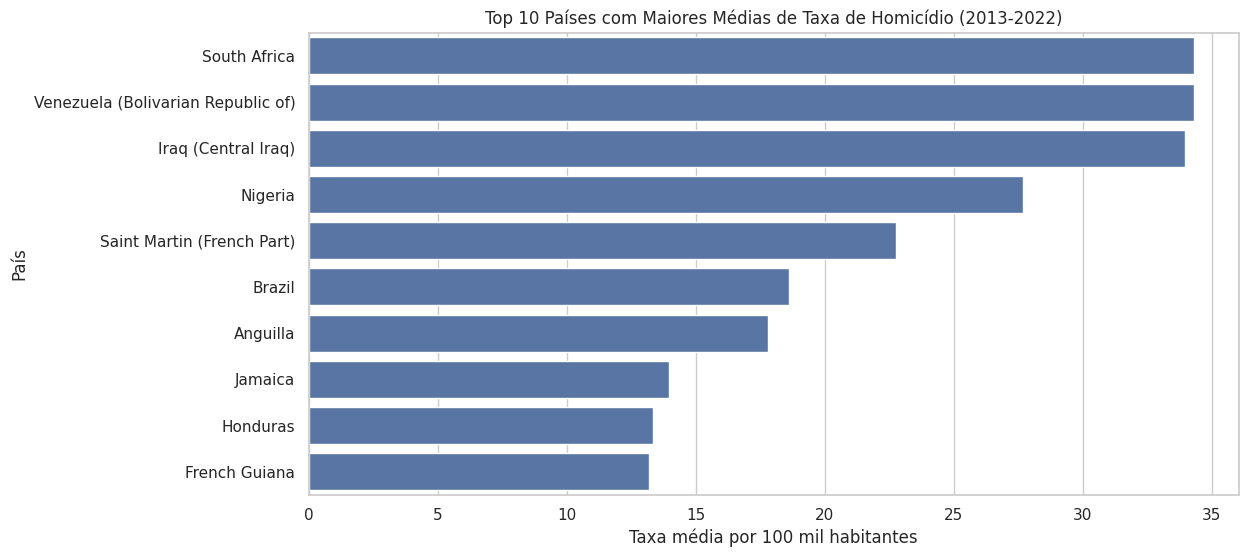

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_paises.values,
    y=top_paises.index
)

plt.title("Top 10 Países com Maiores Médias de Taxa de Homicídio (2013-2022)")
plt.xlabel("Taxa média por 100 mil habitantes")
plt.ylabel("País")

plt.show()

**Pergunta 1 - Quais países apresentam os 10 maiores índices de homicídios nos últimos 5 anos?**

In [ ]:
ultimos_5 = homicidios[
    homicidios["Year"] >= 2018
]

In [ ]:
top10 = (
    ultimos_5
    .groupby("Country")["VALUE"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10

,VALUE
Country,
Iraq (Central Iraq),39.910609
South Africa,35.779754
Venezuela (Bolivarian Republic of),22.468721
Nigeria,21.740789
American Samoa,13.423096
Brazil,13.292863
French Guiana,13.200023
Jamaica,12.795411
Puerto Rico,12.567775


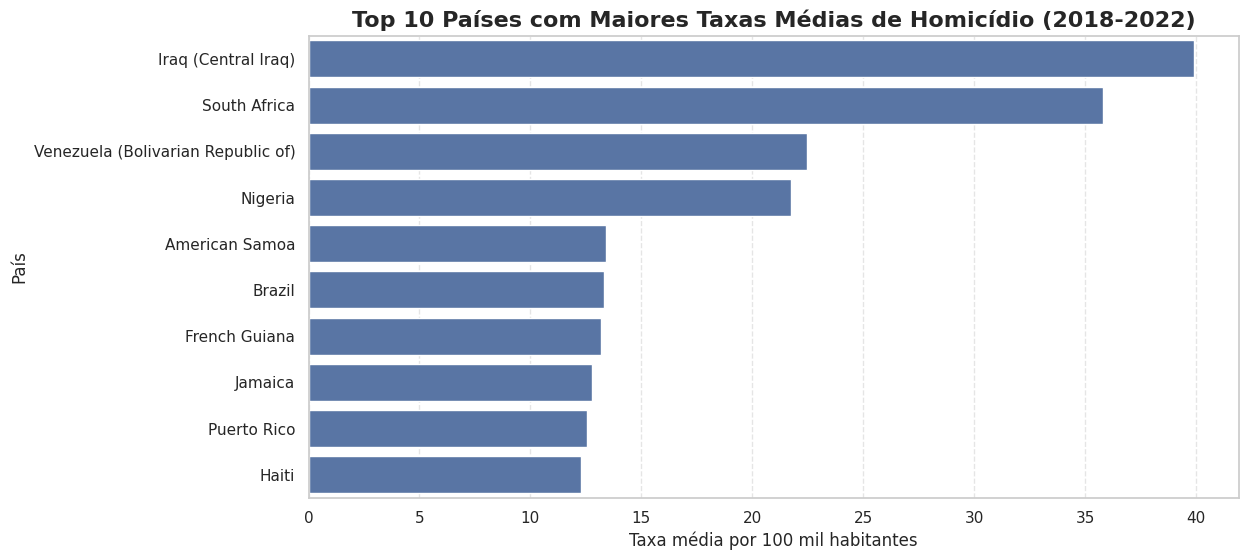

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title(
    "Top 10 Países com Maiores Taxas Médias de Homicídio (2018-2022)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Taxa média por 100 mil habitantes", fontsize=12)
plt.ylabel("País", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

**Pergunta 2 - Quais países apresentam os 10 maiores índices de homicídios de mulheres em 2022?**

In [ ]:
mulheres_2022 = df[
    (df["Indicator"] == "Victims of intentional homicide") &
    (df["Sex"] == "Female") &
    (df["Unit of measurement"] == "Rate per 100,000 population") &
    (df["Year"] == 2022)
]

In [ ]:
top_mulheres = (
    mulheres_2022
    .groupby("Country")["VALUE"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_mulheres

,VALUE
Country,
Saint Lucia,4.669889
Jamaica,4.175955
Mexico,3.892572
Kenya,3.449769
Haiti,3.095983
Puerto Rico,3.084502
Saint Vincent and the Grenadines,3.080055
United States of America,2.755988
Belize,2.641947


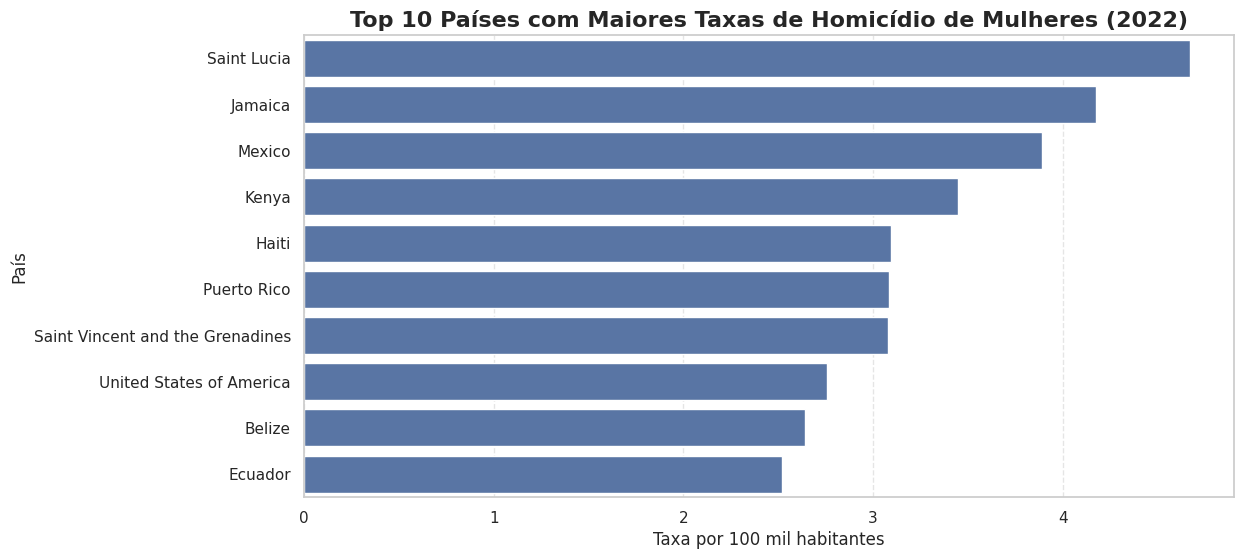

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_mulheres.values,
    y=top_mulheres.index
)

plt.title(
    "Top 10 Países com Maiores Taxas de Homicídio de Mulheres (2022)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Taxa por 100 mil habitantes", fontsize=12)
plt.ylabel("País", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

**Pergunta 3 - Quais as regiões com mais homicídios?**

In [ ]:
regioes = (
    homicidios
    .groupby("Region")["VALUE"]
    .mean()
    .sort_values(ascending=False)
)

regioes

,VALUE
Region,
Americas,5.595460
Africa,2.352568
Oceania,1.134564
Asia,1.035240
Europe,0.475159


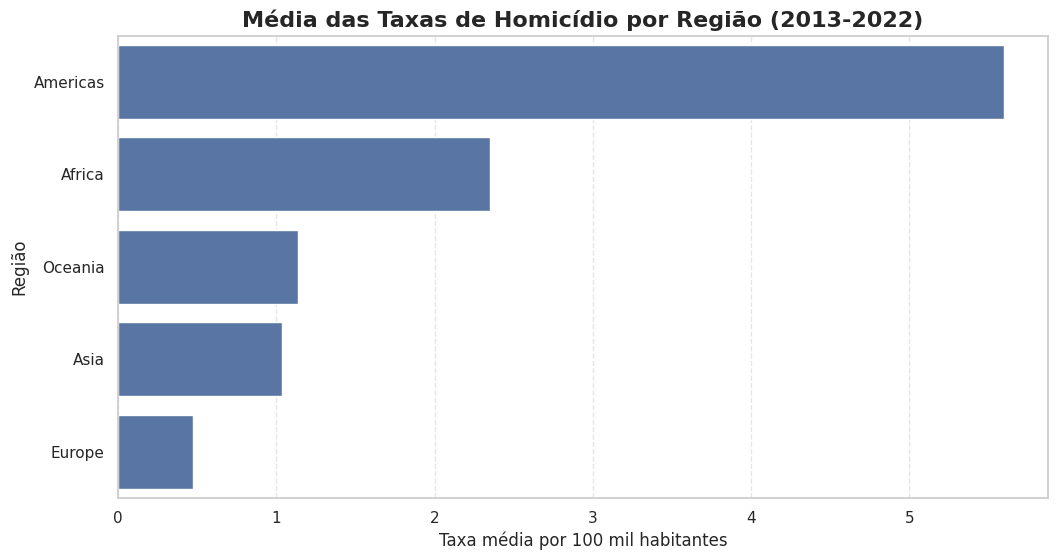

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=regioes.values,
    y=regioes.index
)

plt.title(
    "Média das Taxas de Homicídio por Região (2013-2022)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Taxa média por 100 mil habitantes", fontsize=12)
plt.ylabel("Região", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()